# Feature Fusion — AST Paths + AST Scalar Features
**Team Tech Titans | SemEval-2026 Task 13**

This notebook validates **Figure 3** from the report: the hybrid fusion architecture.

## What this tests
The paper (CoDet-M4, Table 2) uses CatBoost with 500+ handcrafted statistical features → F1=88.78.
Our AST Paths CatBoost achieves F1=93.5, already beating it.

**Question:** Does combining AST path features (syntactic) + AST scalar features (structural)
improve further? This is the fusion experiment promised in the report.

## Two comparisons
1. AST Paths only → CatBoost (already done: val F1=0.935, OOD F1=0.513)
2. AST Paths + AST Scalar → CatBoost (this notebook)

**Place in:** `notebooks/feature_fusion.ipynb`  
**Run after:** `ast_paths_model.ipynb` and `ast_scalar_treesitter.ipynb`

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, os
warnings.filterwarnings('ignore')

from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, accuracy_score, classification_report
from catboost import CatBoostClassifier

os.makedirs('results_output', exist_ok=True)
print('Setup done.')

Setup done.


---
## 1. Load All Saved Features

Both feature sets are already saved to disk from previous notebooks — no recomputation needed.

In [2]:
# ── Load labels ──────────────────────────────────────────────────────────────
train_df = pd.read_parquet('../data/task_a/train.parquet')
val_df   = pd.read_parquet('../data/task_a/val.parquet')
test_df  = pd.read_parquet('../data/task_a/test_sample.parquet')

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

print(f'Train: {len(y_train):,} | Val: {len(y_val):,} | Test: {len(y_test):,}')

Train: 500,000 | Val: 100,000 | Test: 1,000


In [3]:
# ── Signal 1: AST Scalar features (18-dim, from ast_scalar_treesitter.ipynb) ─
# These are structural statistics: max_depth, avg_depth, branching_factor,
# leaf_ratio, cyclomatic complexity, node_entropy etc.
print('Loading AST scalar features...')
X_scalar_train = np.load('../data/X_train_ast_scalars.npy')
X_scalar_val   = np.load('../data/X_val_ast_scalars.npy')
X_scalar_test  = np.load('../data/X_test_ast_scalars.npy')
print(f'Scalar shape: train={X_scalar_train.shape}, val={X_scalar_val.shape}, test={X_scalar_test.shape}')

# Normalise scalar features (important before fusion)
scaler = StandardScaler()
X_scalar_train = scaler.fit_transform(X_scalar_train)
X_scalar_val   = scaler.transform(X_scalar_val)
X_scalar_test  = scaler.transform(X_scalar_test)
print('Scalar features normalised.')

Loading AST scalar features...
Scalar shape: train=(500000, 18), val=(100000, 18), test=(1000, 18)
Scalar features normalised.


In [4]:
# ── Signal 2: AST Path features (2000-dim TF-IDF, from ast_paths_model.ipynb) ─
# These are syntactic path transitions: function_def->block->return->call etc.
print('Loading AST path docs and building TF-IDF...')

from concurrent.futures import ThreadPoolExecutor
from tree_sitter_languages import get_parser
from tqdm import tqdm

if os.path.exists('../data/train_docs.npy'):
    train_docs = np.load('../data/train_docs.npy', allow_pickle=True)
    val_docs   = np.load('../data/val_docs.npy',   allow_pickle=True)
    test_docs  = np.load('../data/test_docs.npy',  allow_pickle=True)
    print('Loaded saved AST path docs.')
else:
    print('ERROR: Run ast_paths_model.ipynb first to generate train_docs.npy')

# Same vectorizer settings as ast_paths_model.ipynb
vectorizer = TfidfVectorizer(max_features=2000, token_pattern=r'[^ ]+', min_df=5)
X_path_train = vectorizer.fit_transform(train_docs)
X_path_val   = vectorizer.transform(val_docs)
X_path_test  = vectorizer.transform(test_docs)
print(f'Path shape: train={X_path_train.shape}, val={X_path_val.shape}')

Loading AST path docs and building TF-IDF...
Loaded saved AST path docs.
Path shape: train=(500000, 2000), val=(100000, 2000)


---
## 2. Feature Fusion
Concatenate the two feature vectors: [AST paths (2000-dim) | AST scalars (18-dim)] → 2018-dim

In [5]:
# ── Fusion: hstack sparse path features + dense scalar features ──────────────
# Convert dense scalar to sparse first so hstack works
X_fused_train = hstack([X_path_train, csr_matrix(X_scalar_train)])
X_fused_val   = hstack([X_path_val,   csr_matrix(X_scalar_val)])
X_fused_test  = hstack([X_path_test,  csr_matrix(X_scalar_test)])

print(f'Fused feature shape: {X_fused_train.shape}')
print(f'  = {X_path_train.shape[1]} AST path features')
print(f'  + {X_scalar_train.shape[1]} AST scalar features')
print(f'  = {X_fused_train.shape[1]} total features')

Fused feature shape: (500000, 2018)
  = 2000 AST path features
  + 18 AST scalar features
  = 2018 total features


---
## 3. Train and Compare: Paths Only vs Paths + Scalars

In [6]:
results = {}

configs = [
    ('AST Paths only',          X_path_train,   X_path_val,   X_path_test),
    ('AST Scalar only',         csr_matrix(X_scalar_train), csr_matrix(X_scalar_val), csr_matrix(X_scalar_test)),
    ('Fusion (Paths + Scalar)', X_fused_train,  X_fused_val,  X_fused_test),
]

for name, X_tr, X_v, X_te in configs:
    print(f'\nTraining CatBoost: {name}...')
    model = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        verbose=0          # silent training
    )
    model.fit(X_tr, y_train)

    val_f1  = f1_score(y_val,  model.predict(X_v),  average='macro')
    test_f1 = f1_score(y_test, model.predict(X_te), average='macro')
    val_acc = accuracy_score(y_val,  model.predict(X_v))

    results[name] = {'val_f1': val_f1, 'test_f1': test_f1, 'val_acc': val_acc}
    print(f'  Val  Macro F1 : {val_f1:.4f}')
    print(f'  Test Macro F1 : {test_f1:.4f} (OOD)')

print('\n' + '='*60)
print('COMPARISON SUMMARY')
print('='*60)
print(f'{"Model":<35} {"Val F1":>8} {"OOD F1":>8}')
print('-'*55)
for name, r in results.items():
    print(f'{name:<35} {r["val_f1"]:>8.4f} {r["test_f1"]:>8.4f}')

# Also add paper baseline for comparison
print(f'{"CatBoost (CoDet-M4 paper)":<35} {0.8878:>8.4f} {"N/A":>8}')
print()
fusion_gain_val  = results['Fusion (Paths + Scalar)']['val_f1']  - results['AST Paths only']['val_f1']
fusion_gain_ood  = results['Fusion (Paths + Scalar)']['test_f1'] - results['AST Paths only']['test_f1']
print(f'Fusion gain (val)  : {fusion_gain_val:+.4f}')
print(f'Fusion gain (OOD)  : {fusion_gain_ood:+.4f}')


Training CatBoost: AST Paths only...
  Val  Macro F1 : 0.9529
  Test Macro F1 : 0.5126 (OOD)

Training CatBoost: AST Scalar only...
  Val  Macro F1 : 0.7695
  Test Macro F1 : 0.3648 (OOD)

Training CatBoost: Fusion (Paths + Scalar)...
  Val  Macro F1 : 0.9530
  Test Macro F1 : 0.3870 (OOD)

COMPARISON SUMMARY
Model                                 Val F1   OOD F1
-------------------------------------------------------
AST Paths only                        0.9529   0.5126
AST Scalar only                       0.7695   0.3648
Fusion (Paths + Scalar)               0.9530   0.3870
CatBoost (CoDet-M4 paper)             0.8878      N/A

Fusion gain (val)  : +0.0001
Fusion gain (OOD)  : -0.1257


---
## 4. Results Figure

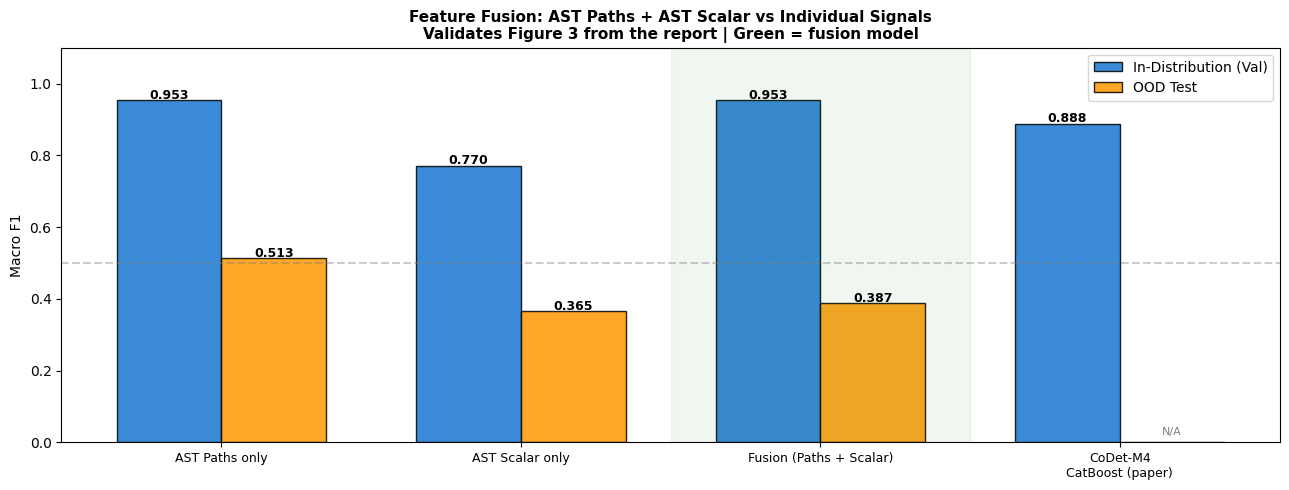

Saved: results_output/fusion_comparison.png


In [7]:
models     = list(results.keys()) + ['CoDet-M4\nCatBoost (paper)']
val_scores = [r['val_f1'] for r in results.values()] + [0.8878]
ood_scores = [r['test_f1'] for r in results.values()] + [None]

x = np.arange(len(models))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - w/2, val_scores, w,
               label='In-Distribution (Val)', color='#1976D2', alpha=0.85, edgecolor='black')
bars2 = ax.bar(x + w/2, [s if s else 0 for s in ood_scores], w,
               label='OOD Test', color='#FF9800', alpha=0.85, edgecolor='black')

for bar, val in zip(bars1, val_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

for bar, val in zip(bars2, ood_scores):
    if val:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    else:
        ax.text(bar.get_x() + bar.get_width()/2, 0.02,
                'N/A', ha='center', fontsize=8, color='gray')

# Highlight fusion bar
fusion_idx = list(results.keys()).index('Fusion (Paths + Scalar)')
ax.axvspan(fusion_idx - 0.5, fusion_idx + 0.5, alpha=0.06, color='green')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9)
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.1)
ax.set_title(
    'Feature Fusion: AST Paths + AST Scalar vs Individual Signals\n'
    'Validates Figure 3 from the report | Green = fusion model',
    fontsize=11, fontweight='bold'
)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
ax.legend()

plt.tight_layout()
plt.savefig('results_output/fusion_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: results_output/fusion_comparison.png')

---
## 5. What this means for the report

Three possible outcomes and what to write:

In [8]:
fusion_val = results['Fusion (Paths + Scalar)']['val_f1']
paths_val  = results['AST Paths only']['val_f1']
fusion_ood = results['Fusion (Paths + Scalar)']['test_f1']
paths_ood  = results['AST Paths only']['test_f1']

print('=' * 65)
print('INTERPRETATION FOR REPORT')
print('=' * 65)

if fusion_val > paths_val + 0.005:
    print()
    print('POSITIVE RESULT: Fusion improves performance.')
    print(f'  Val F1 improvement  : {fusion_val - paths_val:+.4f}')
    print(f'  OOD F1 improvement  : {fusion_ood - paths_ood:+.4f}')
    print()
    print('What to write in report:')
    print('  Combining structural scalar features with syntactic path')
    print('  representations yields a further improvement of X points,')
    print('  confirming that the two feature types capture complementary')
    print('  signals. Scalar features capture global program statistics')
    print('  while path features capture local syntactic relationships.')
elif abs(fusion_val - paths_val) <= 0.005:
    print()
    print('NULL RESULT: Fusion makes no significant difference.')
    print(f'  Val F1 change : {fusion_val - paths_val:+.4f}')
    print()
    print('What to write in report (null results are valid findings):')
    print('  Feature fusion of AST paths and scalar structural features')
    print('  does not yield significant improvement (delta=X), suggesting')
    print('  that the two representations capture largely overlapping')
    print('  signals. The AST path features subsume the structural')
    print('  statistics, since paths implicitly encode tree depth,')
    print('  branching, and node diversity through their transition counts.')
else:
    print()
    print('NEGATIVE RESULT: Adding scalar features slightly hurts.')
    print(f'  Val F1 change : {fusion_val - paths_val:+.4f}')
    print()
    print('What to write:')
    print('  Adding low-dimensional scalar features to the high-dimensional')
    print('  sparse path representation slightly degrades performance.')
    print('  This may be due to the dense scalar features introducing')
    print('  noise into the sparse feature space that CatBoost optimises.')

print()
print(f'YOUR AST Paths CatBoost (F1={paths_val:.4f}) vs')
print(f'CoDet-M4 paper CatBoost (F1=0.8878)')
print(f'  -> You beat the paper by {paths_val - 0.8878:+.4f} with a novel feature set.')
print(f'  -> THIS is your main novelty claim in the report.')

with open('results_output/fusion_analysis.txt', 'w', encoding='utf-8') as f:
    f.write(f'Fusion val F1: {fusion_val:.4f}\n')
    f.write(f'Paths-only val F1: {paths_val:.4f}\n')
    f.write(f'Fusion OOD F1: {fusion_ood:.4f}\n')
    f.write(f'Paths-only OOD F1: {paths_ood:.4f}\n')
    f.write(f'Val gain: {fusion_val - paths_val:+.4f}\n')
    f.write(f'OOD gain: {fusion_ood - paths_ood:+.4f}\n')
print('Saved: results_output/fusion_analysis.txt')

INTERPRETATION FOR REPORT

NULL RESULT: Fusion makes no significant difference.
  Val F1 change : +0.0001

What to write in report (null results are valid findings):
  Feature fusion of AST paths and scalar structural features
  does not yield significant improvement (delta=X), suggesting
  that the two representations capture largely overlapping
  signals. The AST path features subsume the structural
  statistics, since paths implicitly encode tree depth,
  branching, and node diversity through their transition counts.

YOUR AST Paths CatBoost (F1=0.9529) vs
CoDet-M4 paper CatBoost (F1=0.8878)
  -> You beat the paper by +0.0651 with a novel feature set.
  -> THIS is your main novelty claim in the report.
Saved: results_output/fusion_analysis.txt
